In [1]:
import json
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import defaultdict
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from ollama import Client

from utils import dataset_utils
from datasets.mvtec_dataset import MVTecDataset
from moviad.utilities.configurations import TaskType, LabelName

In [2]:
client = Client(host="http://localhost:6000")
os.environ["CUDA_VISIBLE_DEVICES"] = ""
MODEL_NAME = "gemma3:12b"
categories = ["hazelnut", "screw", "carpet"]
dataset_path = "/mnt/disk1/borsattifr/datasets/mvtec"

## Create concept list

In [ ]:
for category in categories:

    concepts = set()

    train_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = "train")
    train_dataset.load_dataset()

    test_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = "test")
    test_dataset.load_dataset()

    anomalous_samples = test_dataset.samples[test_dataset.samples.label_index == LabelName.ABNORMAL]
    print(f"Number of anomalous images: {len(anomalous_samples)}")

    normal_test_samples = test_dataset.samples[test_dataset.samples.label_index == LabelName.NORMAL]
    normal_samples = pd.concat([train_dataset.samples, normal_test_samples])
    print(f"Number of normal images: {len(normal_samples)}")

    for i in range(len(normal_samples)):
        sample = normal_samples.iloc[i]
        concept_json = dataset_utils.first_vlm_query(category, MODEL_NAME, sample, anomalous = False)
        concepts.update(c.lower() for c in concept_json)
        
    
    for i in range(len(anomalous_samples)):
        sample = anomalous_samples.iloc[i]
        concept_json = dataset_utils.first_vlm_query(category, MODEL_NAME, sample, anomalous = True)
        concepts.update(c.lower() for c in concept_json)

    concepts = list(concepts)
    
    with open(f"{category}_concepts.json", "w") as f:
        json.dump(concepts, f)


## Inspect list

In [6]:
def number_of_concepts(category):
    path = f"concept_lists/original/{category}_concepts.json"
    with open(path, "r") as f:
        concepts = json.load(f)
    print(f"Original number of concepts for {category}:", len(concepts))
    return concepts

In [7]:
original_hazelnut_concepts = number_of_concepts("hazelnut")
original_carpet_concepts = number_of_concepts("carpet")
original_screw_concepts = number_of_concepts("screw")


Original number of concepts for hazelnut: 149
Original number of concepts for carpet: 161
Original number of concepts for screw: 229


### First step: cluster together similar words and retain only one of them

In [ ]:
def cluster_concept_embeddings(concepts, category):
    model = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = model.encode(concepts)

    clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=0.5, linkage="average")
    labels = clustering.fit_predict(embeddings)

    grouped = defaultdict(list)
    for concept, label in zip(concepts, labels):
        grouped[label].append(concept)

    grouped_concepts = list(grouped.values())

    filtered_concepts = []
    for sublist in grouped_concepts:
        filtered_concepts.append(sublist[0])

    print(f"Number of filtered concepts for {category}:", len(filtered_concepts))
    return filtered_concepts

In [ ]:
filtered_hazelnut_concepts = cluster_concept_embeddings(original_hazelnut_concepts, category = "hazelnut")
filtered_carpet_concepts = cluster_concept_embeddings(original_carpet_concepts, category = "carpet")
filtered_screw_concepts = cluster_concepts_embeddings(original_screw_concepts, category = "screw")

Number of filtered concepts for hazelnut: 133
Number of filtered concepts for carpet: 144
Number of filtered concepts for screw: 181


### Second step: query an LLM to aggregate logically similar concepts

In [10]:
def filter_concepts(concepts, category):

    message = "You are an industrial expert that is performing the task of visual anomaly detection."\
            f"Given the following list of visual concepts: {concepts}, related to images of a {category}, please group together those that refer to the same LITERAL meaning, i.e. if they share key words, spelling..."\
            "Ignore semantic relationships, focus only on literal wording and string similarity."\
            "Moreover, choose a representative attribute that best summarizes the group."\
            "I provide two examples: 1. 'Elliptical shape': ['ellipsoidal shape', 'ellipsoid shape', 'elliptical shape']"\
            "2. 'Smooth texture': ['natural texture, 'smooth texture', 'smooth surface texture', 'smooth appearance', 'organic texture', 'uniform texture', 'consistent texture']"\
            "DO NOT create groups that are too general, e.g. grouping together all colours or all textures. Representative concepts should still be able to clearly discriminate between normal and anomalous images."\
            "Return the output as a JSON dictionary where each key is the representative concept, and its value is the list of similar concepts grouped with it."\
            "In case of concepts that cannot be grouped with any other concept, the dictionary should have both as key and value the concept itself."\
            "Please, output ONLY the JSON dictionary."

    response = client.chat(model=MODEL_NAME, messages=[{"role": "user", "content": message}])

    try:
        concept_json = dataset_utils.extract_json(response["message"]["content"])
    except Exception as e:
        print(f"Error parsing response: {e}")
        concept_json = []
    
    print(f"Number of concepts extracted by the LLM for {category}:", len(concept_json))
    print(f"Extracted concepts for {category}:", concept_json.keys())

    with open(f"concept_lists/filtered/{category}_concepts.json", "w") as f:
        json.dump(concept_json, f)

## Final Dataset creation

### Load the final concept list

In [4]:
def load_concepts(category):
    with open(f"concept_lists/filtered/{category}_concepts.json", "r") as f:
        filtered_concepts = json.load(f)

    final_concepts = list(filtered_concepts.keys())

    return final_concepts

In [5]:
final_hazelnut_concepts = load_concepts("hazelnut")
final_carpet_concepts = load_concepts("carpet")
final_screw_concepts = load_concepts("screw")

### VLM prompting

In [ ]:
def create_final_dataset(category, final_concepts):
    normal_images_concepts = []
    anomalous_images_concepts = []

    train_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = "train")
    train_dataset.load_dataset()

    test_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = "test")
    test_dataset.load_dataset()

    anomalous_samples = test_dataset.samples[test_dataset.samples.label_index == LabelName.ABNORMAL]
    print(f"Number of anomalous images: {len(anomalous_samples)}")

    normal_test_samples = test_dataset.samples[test_dataset.samples.label_index == LabelName.NORMAL]
    normal_samples = pd.concat([train_dataset.samples, normal_test_samples])
    print(f"Number of normal images: {len(normal_samples)}")

    for i in range(len(normal_samples)):
        sample = normal_samples.iloc[i]
        concept_vector = dataset_utils.second_vlm_query(category, MODEL_NAME, sample, final_concepts, anomalous = False)
        normal_images_concepts.append(concept_vector)

    normal_concepts_df = pd.DataFrame(normal_images_concepts, columns = [f"{c}" for c in final_concepts])
    normal_samples = pd.concat([normal_samples.reset_index(drop=True), normal_concepts_df], axis = 1)
    print("End of normal images") 

    for i in range(len(anomalous_samples)):
        sample = anomalous_samples.iloc[i]
        concept_vector_anomalous = dataset_utils.second_vlm_query(category, MODEL_NAME, sample, final_concepts, anomalous = True)
        anomalous_images_concepts.append(concept_vector_anomalous)

    anomalous_concepts_df = pd.DataFrame(anomalous_images_concepts, columns = [f"{c}" for c in final_concepts])
    anomalous_samples = pd.concat([anomalous_samples.reset_index(drop=True), anomalous_concepts_df], axis = 1)
    print("End of anomalous images") 

    final_df = pd.concat([normal_samples, anomalous_samples], ignore_index = True)

    final_df.to_csv(f"/mnt/disk1/arianna_stropeni/cbm_data/mvtec/{category}_dataset_automated.csv", index = False)

In [10]:
create_final_dataset("carpet", final_carpet_concepts)

Number of anomalous images: 89
Number of normal images: 308


KeyboardInterrupt: 

## Adjust and split dataframe

In [18]:
def read_csv(path):
    final_df = pd.read_csv(path)
    return final_df

In [ ]:
path_screw = "/mnt/disk1/arianna_stropeni/cbm_data/mvtec/screw_dataset.csv"
screw_df = read_csv(path_screw)

In [55]:
def adjust_columns(df):
    #define the anomaly type
    if "label" in df.columns:
        df = df.rename(columns={"label": "anomaly_type"})

    #drop unnecessary columns
    if "split" in df.columns or "path" in df.columns:
        df = df.drop(columns = ["path", "split"])

    return df

In [56]:
screw_df = adjust_columns(screw_df)

In [68]:
def split_dataframe(df, category, train_size = 0.85, test_size = 0.5):   
    train_df, val_test_df = train_test_split(df, train_size = train_size, stratify=df["anomaly_type"], shuffle = True)

    val_df, test_df = train_test_split(val_test_df, test_size=test_size, shuffle = True)

    train_df["split"] = "train"
    val_df["split"] = "val"
    test_df["split"] = "test"

    df = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

    summary = df.groupby(["anomaly_type", "split"]).size().unstack(fill_value=0)
    print(summary)

    #save split df
    df.to_csv(f"/mnt/disk1/arianna_stropeni/cbm_data/mvtec/{category}_dataset.csv")

    return df

In [69]:
screw_df = split_dataframe(screw_df, category = "screw")

split              test  train  val
anomaly_type                       
good                 28    307   26
manipulated_front     3     20    1
scratch_head          2     20    2
scratch_neck          2     21    2
thread_side           0     20    3
thread_top            1     20    2


### Remove uninformative concepts

In [89]:
screw_df = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/screw_dataset.csv")

In [94]:
def drop_concepts(df, concepts, num_images):
    existing_concepts = [col for col in concepts if col in df.columns]
    #drop concepts that appear in less than 10 images
    invalid_concepts = df[existing_concepts].sum()[lambda x: x < 10].index
    print("Concepts that appear in less than 10 images:", invalid_concepts)

    df = df.drop(columns=invalid_concepts)

    remaining_concepts = [col for col in existing_concepts if col not in invalid_concepts]
    #drop concepts that appear in more than 95% of the images
    always_present_concepts = df[remaining_concepts].sum()[lambda x: x > num_images * 0.95].index
    print("Concepts that appear in more than 95% of images:", always_present_concepts)

    df = df.drop(columns=always_present_concepts)

    remained_concepts = [col for col in concepts if col in df.columns]

    return df, remained_concepts

In [ ]:
screw_df, remained_screw_concepts = drop_concepts(screw_df, final_screw_concepts, num_images=len(screw_df))

Concepts that appear in less than 10 images: Index([], dtype='object')
Concepts that appear in more than 95% of images: Index([], dtype='object')
18


### Remove highly correlated concepts

In [112]:
def compute_correlation(df, concepts, threshold = 0.9):
    concepts_to_use = [col for col in concepts if col in df.columns]
    correlation_matrix = df[concepts_to_use].corr().abs()

    plt.figure(figsize=(18, 15))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
    plt.show()

    upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] >= threshold)]

    print(f"Concepts with correlation >= {threshold}: {to_drop}")

    df = df.drop(columns = to_drop)

    return df

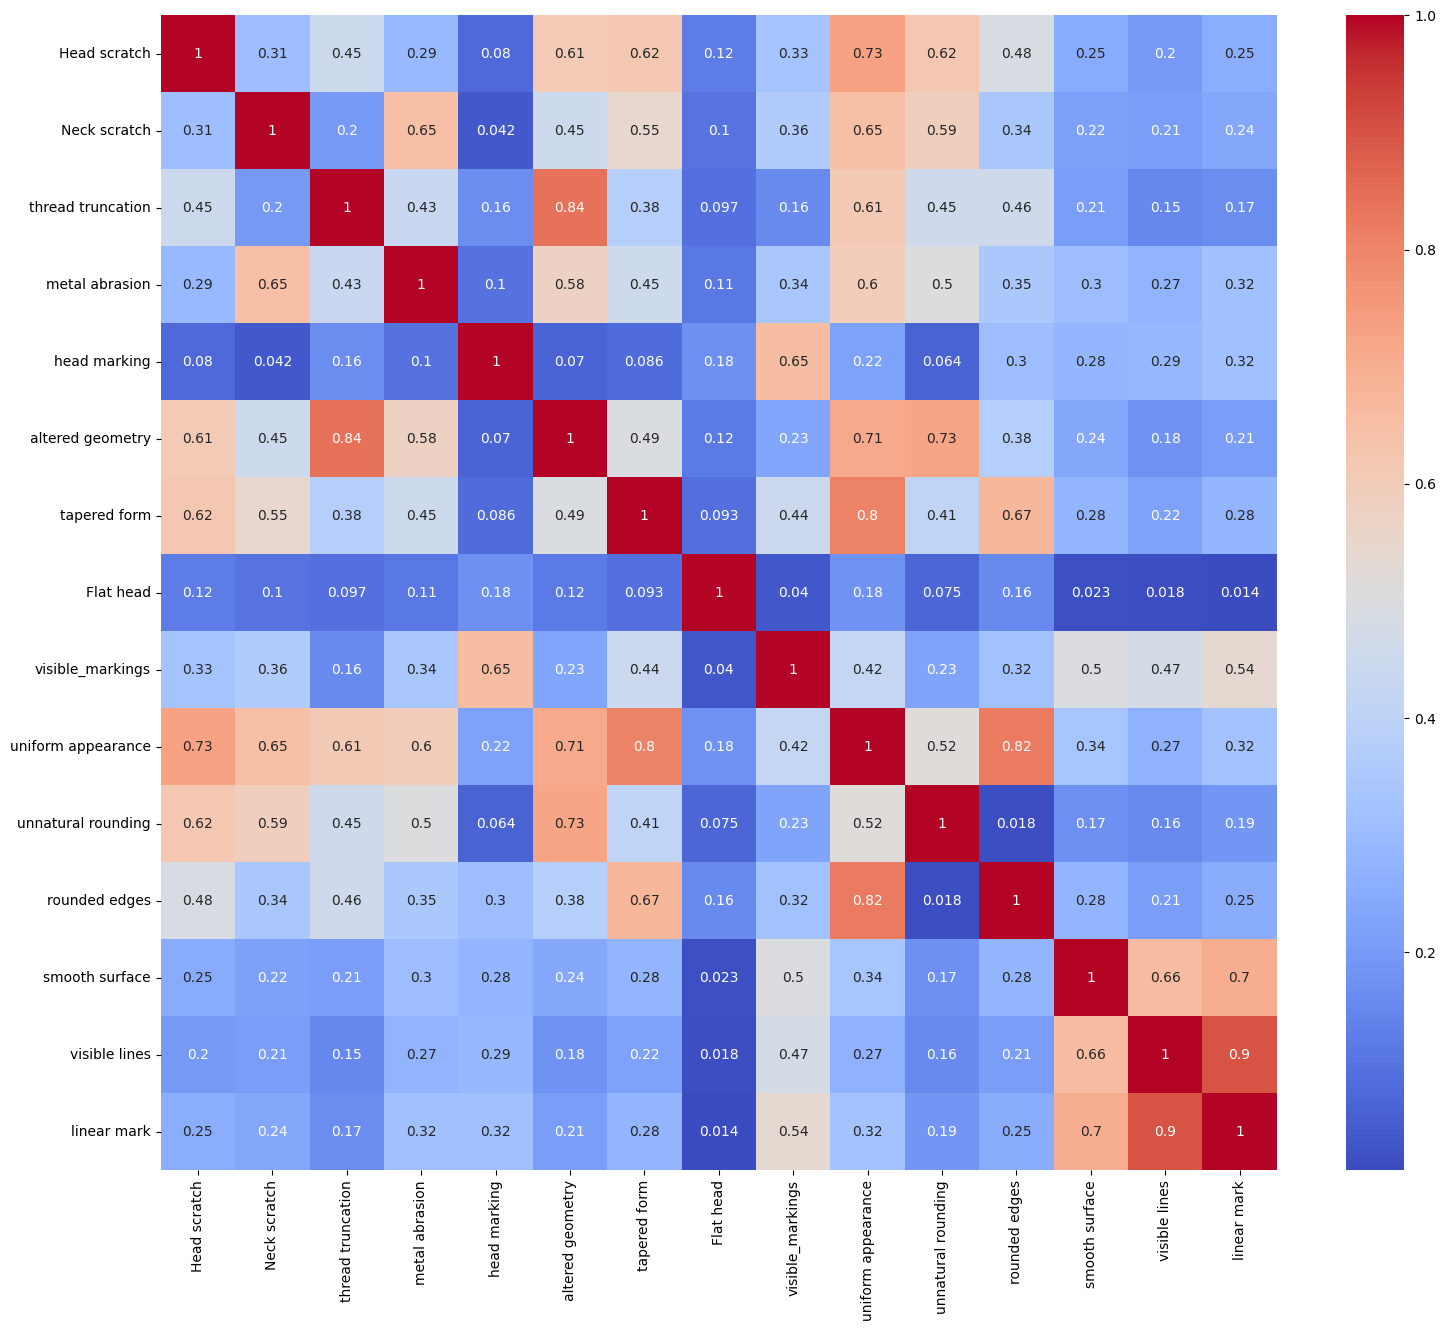

Concepts with correlation >= 0.9: []


In [113]:
screw_df = compute_correlation(screw_df, remained_screw_concepts)

In [115]:
screw_df.to_csv(f"/mnt/disk1/arianna_stropeni/cbm_data/mvtec/screw_dataset.csv")
final_screw_concepts = [col for col in filtered_screw_concepts if col in screw_df.columns]
print("Number of final concepts:", len(final_screw_concepts))

Number of final concepts: 12


## (Optional) Manually check concept annotation

In [23]:
#automatically exclude anomalous concepts
anomalous_concepts = ['Dark Area', 'Color Variation', 'Hole', 'Missing Material', 'Metallic Sheen', 'Unraveling', 'Foreign Object', 'Texture Disruption', 'Damaged Fiber', 'Pattern Disruption']
normal_concepts = ['Consistent Appearance']

final_carpet_df.loc[final_carpet_df["label_index"] == 0, anomalous_concepts] = 0
final_carpet_df.loc[final_carpet_df["label_index"] == 0, normal_concepts] = 1

In [109]:
final_carpet_concepts = ['Hole', 'Dark Area', 'Color Variation', 'Fiber Protrusion', 'Missing Material', 'Metallic Sheen', 'Uneven Distribution', 'Lighter Area', 'Unraveling', 'Foreign Object', 'Texture Disruption', 'Consistent Appearance', 'Exposed Backing', 'Chromatic Anomaly', 'Shadowed Area', 'Spotty Appearance', 'Rectangular Pattern', 'Detached Fiber', 'Damaged Fiber', 'Brown Color', 'Neutral Color', 'Isolated Patch', 'Discoloration', 'Color Discontinuity', 'Pattern Disruption']

In [110]:
final_carpet_df = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/carpet_dataset.csv")

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image as PILImage
import ipywidgets as widgets
import os


# --- Define editable features ---
editable_columns = [col for col in final_carpet_df.columns if col not in ["image_path", "split", "label", "mask_path", "path"]]


def show_image(index):
    print(f"Rendering index {index}")
    row = final_carpet_df.iloc[index]

    img = PILImage.open(row["image_path"])
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {row['label_index']}")
    plt.show()

    # Create input widgets for each editable feature
    editors = {}
    for col in editable_columns:
        value = row[col]
        if isinstance(value, (int, float)):
            editor = widgets.FloatText(value=value, description=col)
        else:
            editor = widgets.Text(value=str(value), description=col)
        editors[col] = editor

    # Button to save edits
    save_button = widgets.Button(description="Save Changes", button_style='success')

    def save_changes(b):
        for col, widget in editors.items():
            final_carpet_df.at[index, col] = widget.value
        print(f"✅ Changes saved for index {index}")

    save_button.on_click(save_changes)

    # Display form
    display(widgets.VBox(list(editors.values()) + [save_button]))


# Interface to scroll through samples
widgets.interact(show_image, index=widgets.IntSlider(min=0, max=len(final_carpet_df)-1, step=1))

interactive(children=(IntSlider(value=0, description='index', max=396), Output()), _dom_classes=('widget-inter…

<function __main__.show_image(index)>

In [114]:
final_carpet_df.to_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/carpet_dataset.csv", index = False)

## (Done) Create complete dataset

In [ ]:
categories = ["bottle", "cable", "capsule", "carpet", "grid", "hazelnut", "leather", "metal_nut", "pill", "screw", "tile", "toothbrush", "transistor", "wood", "zipper"]
full_dataset = pd.DataFrame()

for category in categories:
    for split in ["train", "test"]:
        partial_dataset = MVTecDataset(task = TaskType.SEGMENTATION, root = dataset_path, category = category, split = split)
        partial_dataset.load_dataset()
        partial_dataset.samples["category"] = category

        full_dataset = pd.concat([full_dataset, partial_dataset.samples], ignore_index=True)

full_dataset = full_dataset.reset_index(drop=True)

In [12]:
full_dataset

,path,image_path,label_index,category,mask_path,stratify_key
0,/mnt/disk1/borsattifr/datasets/mvtec/bottle,/mnt/disk1/borsattifr/datasets/mvtec/bottle/tr...,0,bottle,NaN,bottle_0
1,/mnt/disk1/borsattifr/datasets/mvtec/bottle,/mnt/disk1/borsattifr/datasets/mvtec/bottle/tr...,0,bottle,NaN,bottle_0
2,/mnt/disk1/borsattifr/datasets/mvtec/bottle,/mnt/disk1/borsattifr/datasets/mvtec/bottle/tr...,0,bottle,NaN,bottle_0
3,/mnt/disk1/borsattifr/datasets/mvtec/bottle,/mnt/disk1/borsattifr/datasets/mvtec/bottle/tr...,0,bottle,NaN,bottle_0
4,/mnt/disk1/borsattifr/datasets/mvtec/bottle,/mnt/disk1/borsattifr/datasets/mvtec/bottle/tr...,0,bottle,NaN,bottle_0
...,...,...,...,...,...,...
5349,/mnt/disk1/borsattifr/datasets/mvtec/zipper,/mnt/disk1/borsattifr/datasets/mvtec/zipper/te...,1,zipper,/mnt/disk1/borsattifr/datasets/mvtec/zipper/gr...,zipper_1
5350,/mnt/disk1/borsattifr/datasets/mvtec/zipper,/mnt/disk1/borsattifr/datasets/mvtec/zipper/te...,1,zipper,/mnt/disk1/borsattifr/datasets/mvtec/zipper/gr...,zipper_1
5351,/mnt/disk1/borsattifr/datasets/mvtec/zipper,/mnt/disk1/borsattifr/datasets/mvtec/zipper/te...,1,zipper,/mnt/disk1/borsattifr/datasets/mvtec/zipper/gr...,zipper_1
5352,/mnt/disk1/borsattifr/datasets/mvtec/zipper,/mnt/disk1/borsattifr/datasets/mvtec/zipper/te...,1,zipper,/mnt/disk1/borsattifr/datasets/mvtec/zipper/gr...,zipper_1


In [10]:
full_dataset["stratify_key"] = full_dataset["category"].astype(str) + "_" + full_dataset["label_index"].astype(str)

In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_test_df = train_test_split(full_dataset, test_size=0.1, stratify=full_dataset["stratify_key"], shuffle = True)

val_df, test_df = train_test_split(val_test_df, test_size=0.5, stratify = val_test_df["stratify_key"], shuffle = True)

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

full_dataset = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

In [28]:
full_dataset 

,image_path,label_index,category,mask_path,split
0,/mnt/disk1/borsattifr/datasets/mvtec/cable/tes...,0,cable,,train
1,/mnt/disk1/borsattifr/datasets/mvtec/bottle/tr...,0,bottle,NaN,train
2,/mnt/disk1/borsattifr/datasets/mvtec/capsule/t...,0,capsule,NaN,train
3,/mnt/disk1/borsattifr/datasets/mvtec/transisto...,0,transistor,NaN,train
4,/mnt/disk1/borsattifr/datasets/mvtec/carpet/tr...,0,carpet,NaN,train
...,...,...,...,...,...
5349,/mnt/disk1/borsattifr/datasets/mvtec/carpet/te...,1,carpet,/mnt/disk1/borsattifr/datasets/mvtec/carpet/gr...,test
5350,/mnt/disk1/borsattifr/datasets/mvtec/pill/test...,1,pill,/mnt/disk1/borsattifr/datasets/mvtec/pill/grou...,test
5351,/mnt/disk1/borsattifr/datasets/mvtec/bottle/te...,1,bottle,/mnt/disk1/borsattifr/datasets/mvtec/bottle/gr...,test
5352,/mnt/disk1/borsattifr/datasets/mvtec/pill/trai...,0,pill,NaN,test


In [29]:
full_dataset.to_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/full_dataset.csv", index = False)

## Analysis of concepts

### Discriminative analysis


In [24]:
#chi square test
def chi_square_test(df, concepts):
    for col in concepts:
        contingency = pd.crosstab(df[col], df["label_index"])
        chi2, p, dof, ex = chi2_contingency(contingency)
        print(f"{col}: p-value = {p:.2e}")
        prob_anomalous = df[df["label_index"] == 1][col].mean()
        prob_normal = df[df["label_index"] == 0][col].mean()
        print(f"{col}: P(concept=1 | anomaly) = {prob_anomalous:.2f}, P(concept=1 | normal) = {prob_normal:.2f}")

In [26]:
chi_square_test(hazelnut_df, final_hazelnut_concepts)

Crack: p-value = 1.59e-32
Crack: P(concept=1 | anomaly) = 0.33, P(concept=1 | normal) = 0.00
Hole: p-value = 5.68e-40
Hole: P(concept=1 | anomaly) = 0.40, P(concept=1 | normal) = 0.00
Split: p-value = 1.38e-29
Split: P(concept=1 | anomaly) = 0.30, P(concept=1 | normal) = 0.00
Fracture: p-value = 6.71e-57
Fracture: P(concept=1 | anomaly) = 0.56, P(concept=1 | normal) = 0.00
Color Deviation: p-value = 2.44e-22
Color Deviation: P(concept=1 | anomaly) = 0.23, P(concept=1 | normal) = 0.00
Surface Imperfection: p-value = 4.73e-28
Surface Imperfection: P(concept=1 | anomaly) = 1.00, P(concept=1 | normal) = 0.30
Texture Anomaly: p-value = 1.01e-96
Texture Anomaly: P(concept=1 | anomaly) = 0.90, P(concept=1 | normal) = 0.00
Structural Damage: p-value = 1.28e-79
Structural Damage: P(concept=1 | anomaly) = 0.76, P(concept=1 | normal) = 0.00
Visible Mark: p-value = 1.49e-28
Visible Mark: P(concept=1 | anomaly) = 0.49, P(concept=1 | normal) = 0.04
Irregular Shape: p-value = 7.88e-16
Irregular Shape

### Check differences between fully automated dataset and partially automated dataset

In [6]:
hazelnut_df = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/hazelnut_dataset.csv")
hazelnut_df_automated = pd.read_csv("/mnt/disk1/arianna_stropeni/cbm_data/mvtec/hazelnut_dataset_automated.csv")

In [16]:
hazelnut_df

,split,anomaly_type,image_path,label_index,mask_path,Crack,Hole,Split,Fracture,Color Deviation,...,Localized Damage,Visible Crevices,Dark Interior,Broken Shell,Uniform Appearance,Light Streaks,Visible Ink,Ovoid Shape,Spherical Shape,Uneven Tone
0,train,good,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,train,good,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,train,good,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,train,good,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
4,train,good,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,test,good,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
497,test,good,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
498,test,good,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
499,test,good,/mnt/disk1/borsattifr/datasets/mvtec/hazelnut/...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [149]:
concepts_to_remove = [col for col in final_hazelnut_concepts if col not in hazelnut_df.columns]
print(concepts_to_remove)
hazelnut_df_automated = hazelnut_df_automated.drop(columns = concepts_to_remove)

['Sharp Edge', 'Blurred Details', 'Pattern Distortion', 'Dark Line', 'Uniform Color', 'Light Scattering', 'Ellipsoidal Shape']


In [18]:
final_hazelnut_concepts = [col for col in final_hazelnut_concepts if col in hazelnut_df.columns]

In [31]:
indexed_manual = hazelnut_df.set_index("image_path")
indexed_automated = hazelnut_df_automated.set_index("image_path")

In [29]:
def check_differences(df_1, df_2, column_name):
    merged_df = df_1[[column_name]].rename(columns={column_name: f"manual_{column_name}"}).join(df_2[[column_name]].rename(columns={column_name: f"automated_{column_name}"}), how = "inner")
    merged_df["differences"] = merged_df[f"manual_{column_name}"] != merged_df[f"automated_{column_name}"]

    #compute accuracy 
    accuracy = (merged_df[f'manual_{column_name}'] == merged_df[f"automated_{column_name}"]).mean()

    #compute precision and recall
    TP = ((merged_df[f'manual_{column_name}'] == 1) & (merged_df[f"automated_{column_name}"] == 1)).sum()
    TN = ((merged_df[f'manual_{column_name}'] == 0) & (merged_df[f"automated_{column_name}"] == 0)).sum()
    FP = ((merged_df[f'manual_{column_name}'] == 0) & (merged_df[f"automated_{column_name}"] == 1)).sum()
    FN = ((merged_df[f'manual_{column_name}'] == 1) & (merged_df[f"automated_{column_name}"] == 0)).sum()

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0

    print(f"Accuracy of automated concepts for concept {column_name}: {accuracy:.2f}")

    return accuracy, precision, recall

In [40]:
anomaly_concepts_obj = ["Crack", "Hole", "Split", "Fracture", "Visible Mark", "Visible Crevices", "Dark Interior", "Broken Shell", "Visible Ink"]
normal_concepts_obj = ["Intact Shell"]
anomaly_concepts_subj = ["Surface Imperfection", "Texture Anomaly", "Structural Damage", "Irregular Shape", "Surface Discontinuity", "Linear Disruption", "Irregular Edge", "Surface Disruption", "Localized Damage", "Uneven Tone", "Color Deviation"]
normal_concepts_subj = ["Compact Appearance", "Natural Appearance", "Uniform Appearance"]
uniformative_concepts = ["Color Contrast", "Visible Veins", "Irregular Edge", "Light Streaks", "Ovoid Shape", "Spherical Shape"]

In [45]:
all_acc = []
all_prec = []
all_rec = []

for concept in uniformative_concepts:
    accuracy, precision, recall = check_differences(indexed_manual, indexed_automated, concept)
    all_acc.append(accuracy)
    all_prec.append(precision)
    all_rec.append(recall)

Accuracy of automated concepts for concept Color Contrast: 0.63
Accuracy of automated concepts for concept Visible Veins: 0.93
Accuracy of automated concepts for concept Irregular Edge: 0.74
Accuracy of automated concepts for concept Light Streaks: 0.74
Accuracy of automated concepts for concept Ovoid Shape: 0.86
Accuracy of automated concepts for concept Spherical Shape: 0.86


In [34]:
avg_acc, std_acc = np.mean(all_acc), np.std(all_acc)
avg_prec, std_prec = np.mean(all_prec), np.std(all_prec)
avg_rec, std_rec = np.mean(all_rec), np.std(all_rec)

print(f"Average accuracy of anomaly-related objective concepts: {avg_acc:.2f} ± {std_acc:.2f}")
print(f"Average precision of anomaly-related objective concepts: {avg_prec:.2f} ± {std_prec:.2f}")
print(f"Average recall of anomaly-related objective concepts: {avg_rec:.2f} ± {std_rec:.2f}")

Average accuracy of anomaly-related objective concepts: 0.96 ± 0.03
Average precision of anomaly-related objective concepts: 0.71 ± 0.22
Average recall of anomaly-related objective concepts: 0.79 ± 0.25


In [38]:
avg_acc, std_acc = np.mean(all_acc), np.std(all_acc)
avg_prec, std_prec = np.mean(all_prec), np.std(all_prec)
avg_rec, std_rec = np.mean(all_rec), np.std(all_rec)

print(f"Average accuracy of anomaly-related subjective concepts: {avg_acc:.2f} ± {std_acc:.2f}")
print(f"Average precision of anomaly-related subjective concepts: {avg_prec:.2f} ± {std_prec:.2f}")
print(f"Average recall of anomaly-related subjective concepts: {avg_rec:.2f} ± {std_rec:.2f}")

Average accuracy of anomaly-related subjective concepts: 0.87 ± 0.10
Average precision of anomaly-related subjective concepts: 0.65 ± 0.28
Average recall of anomaly-related subjective concepts: 0.66 ± 0.31


In [42]:
avg_acc, std_acc = np.mean(all_acc), np.std(all_acc)
avg_prec, std_prec = np.mean(all_prec), np.std(all_prec)
avg_rec, std_rec = np.mean(all_rec), np.std(all_rec)

print(f"Average accuracy of normality-related objective concepts: {avg_acc:.2f} ± {std_acc:.2f}")
print(f"Average precision of normality-related objective concepts: {avg_prec:.2f} ± {std_prec:.2f}")
print(f"Average recall of normality-related objective concepts: {avg_rec:.2f} ± {std_rec:.2f}")

Average accuracy of normality-related objective concepts: 0.99 ± 0.00
Average precision of normality-related objective concepts: 0.99 ± 0.00
Average recall of normality-related objective concepts: 1.00 ± 0.00


In [44]:
avg_acc, std_acc = np.mean(all_acc), np.std(all_acc)
avg_prec, std_prec = np.mean(all_prec), np.std(all_prec)
avg_rec, std_rec = np.mean(all_rec), np.std(all_rec)

print(f"Average accuracy of normality-related subjective concepts: {avg_acc:.2f} ± {std_acc:.2f}")
print(f"Average precision of normality-related subjective concepts: {avg_prec:.2f} ± {std_prec:.2f}")
print(f"Average recall of normality-related subjective concepts: {avg_rec:.2f} ± {std_rec:.2f}")

Average accuracy of normality-related subjective concepts: 0.98 ± 0.01
Average precision of normality-related subjective concepts: 0.99 ± 0.00
Average recall of normality-related subjective concepts: 0.99 ± 0.01


In [46]:
avg_acc, std_acc = np.mean(all_acc), np.std(all_acc)
avg_prec, std_prec = np.mean(all_prec), np.std(all_prec)
avg_rec, std_rec = np.mean(all_rec), np.std(all_rec)

print(f"Average accuracy of uniformative concepts: {avg_acc:.2f} ± {std_acc:.2f}")
print(f"Average precision of uniformative concepts: {avg_prec:.2f} ± {std_prec:.2f}")
print(f"Average recall of uniformative concepts: {avg_rec:.2f} ± {std_rec:.2f}")

Average accuracy of uniformative concepts: 0.79 ± 0.10
Average precision of uniformative concepts: 0.39 ± 0.26
Average recall of uniformative concepts: 0.41 ± 0.32
